P_1: Andrew S.
P_2: Ricardo M.
D_1: Sky Striker
D_2: Bystial Vanquish Soul


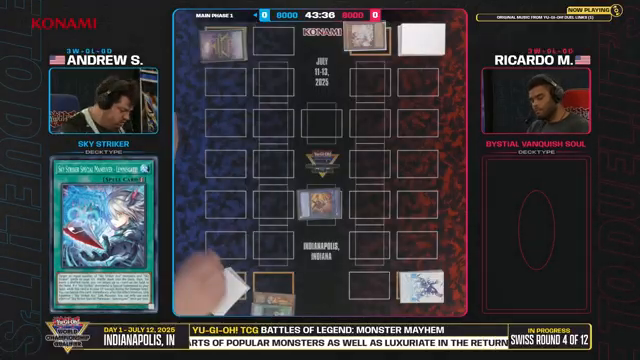

In [3]:
import os
from groq import Groq
from dotenv import load_dotenv
import base64

load_dotenv()
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

import subprocess
from IPython.display import Image, display

VIDEO_URL = "https://www.youtube.com/watch?v=47CNkbmHOSg"
TIMESTAMP = "00:01:30"  # change to whatever time you want
OUTPUT_FRAME = "frame.png"

# Step 1: Download a short clip around the timestamp
subprocess.run([
    "yt-dlp", VIDEO_URL,
    "--download-sections", f"*{TIMESTAMP}-00:05:00",
    "-f", "best[height<=720]",
    "-o", "clip.mp4"
])

# Step 2: Extract a single frame
subprocess.run([
    "ffmpeg", "-i", "clip.mp4",
    "-ss", "00:00:02",   # 2s into the clip
    "-frames:v", "1",
    OUTPUT_FRAME, "-y"
])

with open(OUTPUT_FRAME, "rb") as f:
    b64_frame = base64.b64encode(f.read()).decode("utf-8")

response = client.chat.completions.create(
    model="qwen/qwen3.6-27b",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/png;base64,{b64_frame}"}
                },
                {
                    "type": "text",
                    "text": (
                        "This is a Yu-Gi-Oh match replay frame. "
                        "Reply in exactly this format, with no extra text:\n"
                        "P_1: <player 1>\n"
                        "P_2: <player 2>\n"
                        "D_1: <deck 1>\n"
                        "D_2: <deck 2>"
                    )
                }
            ]
        }
    ],
    max_completion_tokens=60,
    reasoning_effort="none",
)

print(response.choices[0].message.content)

# Still display the frame in notebook
display(Image(OUTPUT_FRAME))

# copied from the EU notebook

In [4]:
import pandas as pd
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("YOUTUBE_API_KEY")
HANDLE = "@OfficialYuGiOhTCG"

# 2. DEFINE LOGIC FUNCTIONS
def get_channel_id_via_api(youtube, handle):
    """Uses the official YouTube API search method to securely resolve a handle 
    into an absolute Channel ID (UC...).
    """
    try:
        response = youtube.search().list(
            q=handle,
            type="channel",
            part="id,snippet",
            maxResults=1
        ).execute()
        
        items = response.get("items", [])
        if not items:
            print(f"Error: Could not find channel with handle: {handle}")
            return None
            
        channel_id = items[0]["id"]["channelId"]
        channel_title = items[0]["snippet"]["title"]
        print(f"Successfully connected to: '{channel_title}'")
        return channel_id
        
    except HttpError as e:
        print(f"An API error occurred while looking up the handle: {e}")
        return None

def fetch_all_playlists(youtube, channel_id):
    """Iterates through all pages of playlists using the YouTube Data API."""
    playlists = []
    next_page_token = None
    
    while True:
        try:
            response = youtube.playlists().list(
                channelId=channel_id,
                part="snippet,contentDetails",
                maxResults=50,
                pageToken=next_page_token
            ).execute()
            
            for item in response.get("items", []):
                playlists.append({
                    "Playlist Title": item["snippet"]["title"],
                    "Video Count": item["contentDetails"]["itemCount"],
                    "Playlist ID": item["id"]
                })
            next_page_token = response.get("nextPageToken")
            if not next_page_token:
                break
        except HttpError as e:
            print(f"An API error occurred while downloading lists: {e}")
            break
    return playlists

C:\Users\Jack Li\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.8) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [5]:
youtube = build("youtube", "v3", developerKey=os.getenv("YOUTUBE_API_KEY"))

channel_id = get_channel_id_via_api(youtube, HANDLE)

if channel_id:
    print(f"Channel ID confirmed as {channel_id}. Fetching playlist data...")
    data = fetch_all_playlists(youtube, channel_id)
    df = pd.DataFrame(data)
    print(f"Done! Extracted {len(df)} total playlists.\n")
    
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_colwidth', None)
    
    # Renders the table visually beneath the cell
    display(df) 
else:
    print("Execution halted: Unable to determine Channel ID.")

Successfully connected to: 'Official Yu-Gi-Oh! TRADING CARD GAME'
Channel ID confirmed as UC8uDq60PstVf56UwH6qfMAA. Fetching playlist data...
Done! Extracted 123 total playlists.



,Playlist Title,Video Count,Playlist ID
0,Chaos Origins,5,PLc1vyOIGc2qXR_Ym2ulQU-JQAwsL6mUs1
1,Battles of Legend: Glorious Gallery,3,PLc1vyOIGc2qU8wh9cPNF82OcKnw5IFccF
2,Blazing Dominion,4,PLc1vyOIGc2qXHIlcNpiK5UnxcUp02mkE-
3,Rarity Collection V,6,PLc1vyOIGc2qW7vPoPEzFNxnV54Q2qIOV6
4,Legendary Modern Decks 2026,5,PLc1vyOIGc2qX01LHO_FEuNuoA_XuYaoxU
5,Maze of Muertos,6,PLc1vyOIGc2qWWWa_DQUZWZILveplhkgBa
6,Burst Protocol,4,PLc1vyOIGc2qUI4GW2HC35oAdIVQF3Dfic
7,THE CHRONICLES DECK: Spirit Charmers (All-Foil Edition),5,PLc1vyOIGc2qWPr-eIR3sM6fq87MHxtnw1
8,Yu-Gi-Oh! CARD GAME THE CHRONICLES,16,PLc1vyOIGc2qWN2TGVP8UJukobWE2BU0qh
9,Yu-Gi-Oh! NEURON App,8,PLc1vyOIGc2qVCM32zSZ6Q5Q8d9S2fgFLr


In [62]:
TARGET_PHRASES = ["YCS", "Championship", "WCQ", "Remote Duel", "Dueling Archives"]
strict_regex = "|".join([rf"\b{word}\b" for word in TARGET_PHRASES])
filtered_df = df[
        df["Playlist Title"].str.contains(strict_regex, case=False, na=False)
        & (df["Playlist Title"] != "Dueling Archives: Scripted Duels")
        & (~df["Playlist Title"].str.contains('Duel Links'))
    ]

print(f"--- Found {len(filtered_df)} playlists matching your target tournament phrases ---")
filtered_df = filtered_df.sort_values(by="Video Count", ascending=False)
display(filtered_df)

--- Found 24 playlists matching your target tournament phrases ---


,Playlist Title,Video Count,Playlist ID
108,Yu-Gi-Oh! World Championship 2019,26,PLc1vyOIGc2qUclsFSVx6fWVI0pI9TQDUp
118,Yu-Gi-Oh! 2015 North American WCQ,24,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt
60,Dueling Archives: North American WCQ 2023,23,PLc1vyOIGc2qWFXx4GRFFbiv3AR1wxD3yV
13,Dueling Archives: NAWCQ Indianapolis,18,PLc1vyOIGc2qX-zEOY_FPbKQtkJVyd-5jM
34,Dueling Archives: 2024 WCQ Austin,18,PLc1vyOIGc2qUPQ3Al4_8S6QJ__QFSVAaO
18,Dueling Archives: YCS Houston 2025,18,PLc1vyOIGc2qUy8UruoP-7uEa-cgG6KRjO
21,Dueling Archives - YCS Orlando 2025,18,PLc1vyOIGc2qVR3zjIHAQmLCdrtFEDZT99
16,Dueling Archives: YCS Providence 2025,17,PLc1vyOIGc2qUdrzkwxpyWPF7hEA-4nxYM
38,Dueling Archives: 2024 YCS Raleigh,17,PLc1vyOIGc2qXZj0ml7PjZVotk9u4BKL8Z
61,"Dueling Archives: 250th YCS: Los Angeles, CA",16,PLc1vyOIGc2qW5Sc7c0ZFOtfPYr4Z5t8Bi


In [112]:
import re
import pandas as pd

# ── Regex ──────────────────────────────────────────────────────────────────────
RE_YEAR     = re.compile(r'(19\d{2}|20\d{2})\b')
RE_YCS      = re.compile(r'\bYCS\b', re.IGNORECASE)
RE_NAWCQ = re.compile(r'\b(?:North\s+American\s+WCQ|NAWCQ|WCQ)\b', re.IGNORECASE)
RE_WQP      = re.compile(r'\bWQP\b', re.IGNORECASE)
RE_WORLDS   = re.compile(r'\bWorld\s+Championship\b', re.IGNORECASE)
RE_REMOTE   = re.compile(r'\bRemote\s+Duel\b', re.IGNORECASE)
RE_DRAGON   = re.compile(r'\bDragon\s+Duel\b', re.IGNORECASE)
RE_DUELING_ARCHIVES = re.compile(r'^\s*Dueling\s+Archives\s*[:\-]\s*', re.IGNORECASE)
RE_REMOTE_CLEAN = re.compile(r'^(Remote\s+Duel\s+Invitational).*', re.IGNORECASE)
RE_NOISE_PREFIX = re.compile(r'^(?:Yu-Gi-Oh!\s*)?\d+(?:st|nd|rd|th)\s+', re.IGNORECASE)
RE_TRAILING_DATES = re.compile(r'\(?\s*(?:\d{1,2}[/\-]\d{1,2}|\w+\s+\d{1,2}).*?\)?\s*$')

def strip_dates(title: str) -> str:
    return RE_TRAILING_DATES.sub("", title).strip(" -:")
    
def normalize_remote(title: str) -> str:
    m = RE_REMOTE_CLEAN.match(title)
    if m:
        return "Remote Duel Invitational"
    return title

def normalize_ycs(title: str) -> str:
    # remove ordinal prefixes like "250th"
    title = RE_NOISE_PREFIX.sub("", title)

    # unify "Yu-Gi-Oh! Championship Series"
    title = re.sub(
        r"Yu-Gi-Oh!\s*Championship\s*Series",
        "YCS",
        title,
        flags=re.IGNORECASE
    )
    
    if "YCS" in title:
        title = "YCS" + title.split("YCS", 1)[1]

    title = re.sub(r"[:\-–—]", " ", title)
    title = re.sub(r"\s+", " ", title).strip()

    return title
    
def get_year(title):
    m = RE_YEAR.search(title)
    return m.group(1) if m else 'Unknown'

def get_category(title):
    if RE_DRAGON.search(title): return "Dragon Duel"
    if RE_WORLDS.search(title): return "World Championship"
    return "Advanced"

def get_clean_title(title):
    title = RE_DUELING_ARCHIVES.sub("", title).strip()
    
    if RE_WORLDS.search(title):
        return f"World Championship"
    if RE_NAWCQ.search(title):
        return f"North American WCQ"
    if RE_WQP.search(title):
        return f"World Qualifying Points"
    if RE_YEAR.search(title):
        return RE_YEAR.sub("", title).strip()
    return title
    
def normalize_title(title: str) -> str:
    title = str(title)

    title = strip_dates(title)

    if "Remote Duel" in title:
        return "Remote Duel Invitational"

    title = normalize_ycs(title)

    title = re.sub(r"\s+", " ", title).strip()

    if title.startswith("YCS"):
        title = "YCS " + title[3:].strip()

    title = title.split(',')[0]

    return title
    
def process(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = ["Playlist Title", "Video Count", "Playlist ID"]

    out["Year"]        = out["Playlist Title"].apply(get_year)
    out["Category"]    = out["Playlist Title"].apply(get_category)
    out["Base Title"]  = out["Playlist Title"].apply(get_clean_title)
    out["Clean Title"] = out["Base Title"].apply(normalize_title)
    return out[[
        "Clean Title", "Year", "Category",
        "Video Count", "Playlist ID", "Playlist Title"
    ]]

result = process(filtered_df)
result


,Clean Title,Year,Category,Video Count,Playlist ID,Playlist Title
108,World Championship,2019,World Championship,26,PLc1vyOIGc2qUclsFSVx6fWVI0pI9TQDUp,Yu-Gi-Oh! World Championship 2019
118,North American WCQ,2015,Advanced,24,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,Yu-Gi-Oh! 2015 North American WCQ
60,North American WCQ,2023,Advanced,23,PLc1vyOIGc2qWFXx4GRFFbiv3AR1wxD3yV,Dueling Archives: North American WCQ 2023
13,North American WCQ,Unknown,Advanced,18,PLc1vyOIGc2qX-zEOY_FPbKQtkJVyd-5jM,Dueling Archives: NAWCQ Indianapolis
34,North American WCQ,2024,Advanced,18,PLc1vyOIGc2qUPQ3Al4_8S6QJ__QFSVAaO,Dueling Archives: 2024 WCQ Austin
18,YCS Houston,2025,Advanced,18,PLc1vyOIGc2qUy8UruoP-7uEa-cgG6KRjO,Dueling Archives: YCS Houston 2025
21,YCS Orlando,2025,Advanced,18,PLc1vyOIGc2qVR3zjIHAQmLCdrtFEDZT99,Dueling Archives - YCS Orlando 2025
16,YCS Providence,2025,Advanced,17,PLc1vyOIGc2qUdrzkwxpyWPF7hEA-4nxYM,Dueling Archives: YCS Providence 2025
38,YCS Raleigh,2024,Advanced,17,PLc1vyOIGc2qXZj0ml7PjZVotk9u4BKL8Z,Dueling Archives: 2024 YCS Raleigh
61,YCS Los Angeles,Unknown,Advanced,16,PLc1vyOIGc2qW5Sc7c0ZFOtfPYr4Z5t8Bi,"Dueling Archives: 250th YCS: Los Angeles, CA"


In [116]:
playlist_ids = result['Playlist ID'].astype(str).tolist()
playlist_ids

['PLc1vyOIGc2qUclsFSVx6fWVI0pI9TQDUp',
 'PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt',
 'PLc1vyOIGc2qWFXx4GRFFbiv3AR1wxD3yV',
 'PLc1vyOIGc2qX-zEOY_FPbKQtkJVyd-5jM',
 'PLc1vyOIGc2qUPQ3Al4_8S6QJ__QFSVAaO',
 'PLc1vyOIGc2qUy8UruoP-7uEa-cgG6KRjO',
 'PLc1vyOIGc2qVR3zjIHAQmLCdrtFEDZT99',
 'PLc1vyOIGc2qUdrzkwxpyWPF7hEA-4nxYM',
 'PLc1vyOIGc2qXZj0ml7PjZVotk9u4BKL8Z',
 'PLc1vyOIGc2qW5Sc7c0ZFOtfPYr4Z5t8Bi',
 'PLc1vyOIGc2qVH_lI0WeiyavM_XOAQoCnH',
 'PLc1vyOIGc2qVGiERh0olzUkkdjXVBzNi3',
 'PLc1vyOIGc2qVxjActmFOJHlVit2Y06w0C',
 'PLc1vyOIGc2qVerc4qlE4na0TZRH0oRUix',
 'PLc1vyOIGc2qVsXghcP-IRPwbIg9yiDTrc',
 'PLc1vyOIGc2qUwKZvwkAIZrfMup6QHDs-1',
 'PLc1vyOIGc2qVX6ZJxab88NnmgUIZLDiLe',
 'PLc1vyOIGc2qUluBlrVlUuTANCWpSAHjGa',
 'PLc1vyOIGc2qX9_zN-CyG1_GTPOvinQZ3Q',
 'PLc1vyOIGc2qXas2XPsp4wKpJDjshieo0N',
 'PLc1vyOIGc2qVA85mAij71b89eAbdruY1u',
 'PLc1vyOIGc2qXdSd5bAVaFUp3BTGDZPwgd',
 'PLc1vyOIGc2qUpHELcFLe4ZE-JVw2enn54',
 'PLc1vyOIGc2qUM7r-X3Abizu4s8qnfQwzG']

In [117]:
import os  # Added to prevent NameError for os.getenv
from googleapiclient.discovery import build
import pandas as pd

def get_playlists_videos(playlist_ids):
    """
    Iterates through a list of YouTube playlist IDs, fetches all video titles,
    descriptions, and video IDs, and returns them in a pandas DataFrame.
    """
    # Initialize the YouTube API client
    youtube = build('youtube', 'v3', developerKey=os.getenv("YOUTUBE_API_KEY"))
    
    video_data = []
    
    for playlist_id in playlist_ids:
        next_page_token = None
        
        # Loop to handle pagination (playlists with more than 50 items)
        while True:
            # Request playlist items
            request = youtube.playlistItems().list(
                part="snippet",
                playlistId=playlist_id,
                maxResults=50,
                pageToken=next_page_token
            )
            response = request.execute()
            
            # Extract title, description, and unique Video ID from each item
            for item in response.get('items', []):
                snippet = item.get('snippet', {})
                title = snippet.get('title', '')
                description = snippet.get('description', '')
                
                # Crucial step: Extract the specific Video ID from the resourceId block
                video_id = snippet.get('resourceId', {}).get('videoId', 'Unknown')
                
                video_data.append({
                    'Playlist ID': playlist_id,
                    'Video ID': video_id,  # <-- Added this field for your URL constructor
                    'Title': title,
                    'Video Description': description # Mapped cleanly to downstream script key
                })
            
            # Check if there's another page of videos
            next_page_token = response.get('nextPageToken')
            if not next_page_token:
                break
                
    # Convert the list of dictionaries into a Pandas DataFrame
    df = pd.DataFrame(video_data)
    return df

# Example Usage:
videos = get_playlists_videos(playlist_ids)

# drop specific titles

In [208]:
pattern = r"round|top|final|all-ages"

mask = df["Title"].str.contains(pattern, case=False, na=False)
ann_mask = df_kept["Title"].str.contains("announcement", case=False, na=False)

df_kept = df[mask]
videos = df_kept[~ann_mask]

print("Kept:", len(df_kept_final))
print("Dropped:", len(df_announcements_dropped))

videos

Kept: 239
Dropped: 2


,Playlist ID,Video ID,Title,Video Description,Round
26,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,68Ym1B0IJOI,Yu-Gi-Oh! 2015 North American WCQ - Round 1,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 1",None
27,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,0KGWKRRzol0,Yu-Gi-Oh! 2015 North American WCQ - Round 2,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 2",None
28,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,9-ycjLAQQLE,Yu-Gi-Oh! 2015 North American WCQ - Round 3,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 3",None
29,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,9LTjuR8pzg8,Yu-Gi-Oh! 2015 North American WCQ - Round 4,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 4",None
31,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,lP2jAvJMwCo,Yu-Gi-Oh! 2015 North American WCQ - Round 6,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 6",None
32,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,cGMCyoV1-ng,Yu-Gi-Oh! 2015 North American WCQ - Round 7,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 7",None
33,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,v5zqJrHl3_c,Yu-Gi-Oh! 2015 North American WCQ - Round 8,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 8",None
34,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,tm4luutQFjE,Yu-Gi-Oh! 2015 North American WCQ - Round 9,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 9",None
35,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,FmM85BABzPU,Yu-Gi-Oh! 2015 North American WCQ - Round 10,"Yu-Gi-Oh! World Championship Qualifier\nNashville, TN\nJune 27-28\nDay 2, Round 10",None
36,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,DZNHH-1WRpM,Yu-Gi-Oh! 2015 North American WCQ - Round 11,"Yu-Gi-Oh! World Championship Qualifier\nNashville, TN\nJune 27-28\nDay 2, Round 11",None


In [203]:
len(videos)

238

# Missing features:


In [209]:
import re

RE_ROUND = re.compile(r"\bround\s*(\d+)\b", re.IGNORECASE)
RE_TOP = re.compile(r"\btop\s*(\d+)\b", re.IGNORECASE)
RE_FINAL = re.compile(r"\b(?:finals?|semi[-\s]?finals?)\b", re.IGNORECASE)

def extract_round(row):
    text = f"{row['Title']} {row['Video Description']}"

    round_match = RE_ROUND.search(text)
    top_match = RE_TOP.search(text)
    final_match = RE_FINAL.search(text)
    
    if round_match:
        return f"Round {round_match.group(1)}"
    if top_match:
        return f"Top {top_match.group(1)}"
    if final_match:
        return f"{final_match.group(0)}"

    return None

videos.loc[:, "Round"] = videos.apply(extract_round, axis=1)

In [214]:
videos

,Playlist ID,Video ID,Title,Video Description,Round
26,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,68Ym1B0IJOI,Yu-Gi-Oh! 2015 North American WCQ - Round 1,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 1",Round 1
27,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,0KGWKRRzol0,Yu-Gi-Oh! 2015 North American WCQ - Round 2,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 2",Round 2
28,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,9-ycjLAQQLE,Yu-Gi-Oh! 2015 North American WCQ - Round 3,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 3",Round 3
29,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,9LTjuR8pzg8,Yu-Gi-Oh! 2015 North American WCQ - Round 4,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 4",Round 4
31,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,lP2jAvJMwCo,Yu-Gi-Oh! 2015 North American WCQ - Round 6,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 6",Round 6
32,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,cGMCyoV1-ng,Yu-Gi-Oh! 2015 North American WCQ - Round 7,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 7",Round 7
33,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,v5zqJrHl3_c,Yu-Gi-Oh! 2015 North American WCQ - Round 8,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 8",Round 8
34,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,tm4luutQFjE,Yu-Gi-Oh! 2015 North American WCQ - Round 9,"2015 North American World Championship Qualifier\nJune 27-28, 2015\nNashville, TN\nDay 1, Round 9",Round 9
35,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,FmM85BABzPU,Yu-Gi-Oh! 2015 North American WCQ - Round 10,"Yu-Gi-Oh! World Championship Qualifier\nNashville, TN\nJune 27-28\nDay 2, Round 10",Round 10
36,PLc1vyOIGc2qXKkGwYHOU-m5dBqMU8FDpt,DZNHH-1WRpM,Yu-Gi-Oh! 2015 North American WCQ - Round 11,"Yu-Gi-Oh! World Championship Qualifier\nNashville, TN\nJune 27-28\nDay 2, Round 11",Round 11


# LLM tagging (not working)

In [151]:
from groq import Groq
import json
import os
import logging
import time

client = Groq(api_key=os.getenv("GROQ_API_KEY"))

# ─────────────────────────────────────────────
# Logging setup
# ─────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger("feature_match_extractor")


# ─────────────────────────────────────────────
# Chunk helper
# ─────────────────────────────────────────────
def chunk_list(data, chunk_size=10):
    for i in range(0, len(data), chunk_size):
        yield i, data[i:i + chunk_size]


# ─────────────────────────────────────────────
# Main extractor
# ─────────────────────────────────────────────
def extract_feature_matches(rows, chunk_size=10):
    all_results = []
    total_chunks = (len(rows) + chunk_size - 1) // chunk_size

    logger.info(
        f"Starting extraction | rows={len(rows)} | chunk_size={chunk_size} | chunks={total_chunks}"
    )

    for idx, chunk in chunk_list(rows, chunk_size):
        chunk_id = idx // chunk_size + 1

        logger.info(f"Processing chunk {chunk_id}/{total_chunks}")

        prompt = """
You are a strict Yu-Gi-Oh! feature match extraction system.

You will receive video data.

TASK:
- Identify ONLY FEATURE MATCH videos
- Ignore livestreams, vlogs, deck profiles, promos, commentary

A feature match is a real duel with identifiable players.

---

OUTPUT RULES (VERY IMPORTANT):

Return ONLY valid JSON array.

Each object must follow this schema:

{
  "is_match": true,
  "tournament": string or null,
  "round": string or null,
  "player_1": string or null,
  "deck_1": string or null,
  "player_2": string or null,
  "deck_2": string or null,
  "playlist_id": string,
  "playlist_name": string,
  "video_id": string,
  "video_name": string,
}

RULES:
- If NOT a feature match, DO NOT include it in output.
- Round must be formatted exactly like: "Round 1", "Round 2", "Top 32", "Finals"
- Tournament should be the event name (e.g. "YCS London 2024", "World Championship 2019")
- Do NOT guess missing players or decks
- Use null if unknown

INPUT:
""" + json.dumps(chunk)
        
        start = time.time()

        try:
            response = client.chat.completions.create(
                model="llama-3.1-8b-instant",                
                messages=[{"role": "user", "content": prompt}],
                temperature=0
            )

            content = response.choices[0].message.content.strip()
            parsed = json.loads(content)

            if isinstance(parsed, list):
                # Inject playlist/video metadata from Python (source of truth)
                enriched = []
                for item, original in zip(parsed, chunk):
                    enriched.append({
                        **item,
                        "playlist_id": original.get("Playlist ID"),
                        "video_id": original.get("Video ID"),
                        "is_match": True  # enforce consistency
                    })

                all_results.extend(enriched)

                logger.info(
                    f"Chunk {chunk_id} success | matches={len(enriched)} | time={time.time() - start:.2f}s"
                )

            else:
                logger.warning(f"Chunk {chunk_id} returned invalid format")

        except json.JSONDecodeError:
            logger.error(f"Chunk {chunk_id} JSON decode failed")
            logger.debug(f"Raw output: {content[:500]}")

        except Exception as e:
            logger.error(f"Chunk {chunk_id} failed | error={str(e)}")

        time.sleep(0.2)

    logger.info(f"Finished | total_matches={len(all_results)}")

    return all_results

In [158]:
rows = videos[["Title", "Video Description"]].to_dict(orient="records")

In [159]:
rows

[{'Title': '🔴 Livestream [DAY 1] – Yu-Gi-Oh! World Championship 2019 – Berlin',
  'Video Description': ''},
 {'Title': '🔴 Livestream [DAY 2]– Yu-Gi-Oh! World Championship 2019 – Berlin',
  'Video Description': ''},
 {'Title': '🔴 Livestream [DAY 2]– Yu-Gi-Oh! World Championship 2019 – Berlin',
  'Video Description': ''},
 {'Title': 'O DIA QUE EU FUI PRO MUNDIAL DE YU GI OH',
  'Video Description': 'Yu Gi Oh um anime que marcou uma geração inteira e com certeza fez parte da sua infância!\n\nObrigado Konami por patrocinar esse vídeo\n\n#YuGiOh #YGOWCS2019 #SouPlayer'},
 {'Title': 'YuGiOh REAL LIFE DUEL | YUGI vs KAIBA!!',
  'Video Description': 'Buy LEGEND of BLUE EYES White Dragon 25th Anniversary HERE ► https://bit.ly/25thAnniversaryYGO\nSubscribe to our Secondary Channel Here ► https://www.youtube.com/@simplyunluckytv\nBuy Cards at Our Game Shop Here  ► https://linktr.ee/simplyunlucky\nFollow SimplyUnlucky on Whatnot for DAILY Giveaways & Live Streams ► https://www.whatnot.com/invite/s

In [152]:
r = extract_feature_matches(rows)

2026-06-27 03:52:28,650 | INFO | Starting extraction | rows=298 | chunk_size=10 | chunks=30
2026-06-27 03:52:28,651 | INFO | Processing chunk 1/30
2026-06-27 03:52:29,399 | INFO | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-27 03:52:29,401 | ERROR | Chunk 1 JSON decode failed
2026-06-27 03:52:29,615 | INFO | Processing chunk 2/30
2026-06-27 03:52:30,129 | INFO | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-27 03:52:30,131 | ERROR | Chunk 2 JSON decode failed
2026-06-27 03:52:30,334 | INFO | Processing chunk 3/30
2026-06-27 03:52:30,353 | INFO | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
2026-06-27 03:52:30,355 | INFO | Retrying request to /openai/v1/chat/completions in 16.000000 seconds
2026-06-27 03:52:46,399 | INFO | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
2026-06-27 03:52:

In [153]:
df = pd.DataFrame(r)
df

,is_match,tournament,round,player_1,deck_1,player_2,deck_2,playlist_id,playlist_name,video_id,video_name
0,True,Yu-Gi-Oh! TRADING CARD GAME World Championship 2024,None,None,None,None,None,None,None,None,Yu-Gi-Oh! TRADING CARD GAME World Championship 2024 – Day 1
1,True,Yu-Gi-Oh! MASTER DUEL World Championship 2024,None,None,None,None,None,None,None,None,Yu-Gi-Oh! MASTER DUEL World Championship 2024 – Day 1
2,True,Yu-Gi-Oh! DUEL LINKS World Championship 2024,None,None,None,None,None,None,None,None,Yu-Gi-Oh! DUEL LINKS World Championship 2024 – Day 1
3,True,Yu-Gi-Oh! TRADING CARD GAME World Championship 2024,None,None,None,None,None,None,None,None,Yu-Gi-Oh! DUEL LINKS | MASTER DUEL | TCG World Championship 2024 – Day 2
4,True,Yu-Gi-Oh! TCG 2019 North America World Championship Qualifier,None,None,None,None,None,None,None,None,Yu-Gi-Oh! TCG 2019 North America World Championship Qualifier - Day 1
5,True,Yu-Gi-Oh! TCG 2019 North America World Championship Qualifier,None,None,None,None,None,None,None,None,Yu-Gi-Oh! TCG 2019 North America World Championship Qualifier - Day 2
6,True,Yu-Gi-Oh! TCG 2019 North America World Championship Qualifier,None,None,None,None,None,None,None,None,Yu-Gi-Oh! TCG 2019 North America World Championship Qualifier - Day 3


In [154]:
df.to_parquet('na_matches.parquet', index=False)